# Attendance Decay Curve (ADC) in Voluntary Student Organizations
### CS506 Data Science Tools and Applications | Boston University | Spring 2026

## Research Question
Do voluntary student organizations at BU exhibit a measurable attendance decay pattern over the course of a semester?

## Hypothesis
Attendance at recurring voluntary org meetings follows a recognizable declining pattern from early to later in the semester — the Attendance Decay Curve (ADC).

## Data Collection
- Population: 302 BU student organizations across 4 SAO categories
- Outreach: 172 organizations contacted via email over multiple waves
- Responses: 19 finished survey responses via Qualtrics
- Usable for slope analysis: 15 organizations with recurring meeting data

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "Attendance Dynamics in BU Student Organizations (Research Survey)_April 17, 2026_12.22.csv"

df_raw = pd.read_csv(CSV_PATH, skiprows=[1, 2])
df_finished = df_raw[df_raw["Finished"].astype(str).str.lower() == "true"].copy()

rec_mask = (
    (df_finished["Q3"] == "Yes")
    & df_finished["Q6"].notna()
    & df_finished["Q7"].notna()
    & df_finished["Q8"].notna()
)
df_rec = df_finished[rec_mask].copy()
for col in ["Q6", "Q7", "Q8"]:
    df_rec[col] = pd.to_numeric(df_rec[col], errors="coerce")
df_rec = df_rec.dropna(subset=["Q6", "Q7", "Q8"]).reset_index(drop=True)

df_rec["Q1"] = df_rec["Q1"].fillna("(anonymous org)")

# Two Pre-Health responses cover different meeting types; distinguish by meeting count
ph_mask_gbm = (df_rec["Q1"] == "Pre-Health Professionals Club") & (df_rec["Q6"] == 5)
ph_mask_spk = (df_rec["Q1"] == "Pre-Health Professionals Club") & (df_rec["Q6"] == 4)
df_rec.loc[ph_mask_gbm, "Q1"] = "Pre-Health Professionals Club (GBM)"
df_rec.loc[ph_mask_spk, "Q1"] = "Pre-Health Professionals Club (speaker events)"

print(f"Loaded {len(df_rec)} recurring orgs")
df_rec[["Q1", "Q2", "Q6", "Q7", "Q8", "Q13"]]

Loaded 15 recurring orgs


,Q1,Q2,Q6,Q7,Q8,Q13
0,(anonymous org),Academic and Pre-Professional,5.0,80.0,60.0,Estimated but close
1,Consulting Group,Academic and Pre-Professional,10.0,44.0,42.0,Estimated but close
2,Delta Kappa Alpha,Performance and Media Arts,7.0,50.0,40.0,Estimated but close
3,Environmental Student Organization,"Community, Peace and Justice",8.0,12.0,21.0,Exact counts from sign-in logs
4,Boston University Artificial Intelligence Society,Academic and Pre-Professional,6.0,30.0,10.0,Rough estimate
5,Alzheimer's Buddies at BU,"Community, Peace and Justice",4.0,30.0,10.0,Estimated but close
6,Data Science Association,Academic and Pre-Professional,7.0,30.0,6.0,Estimated but close
7,SciBU: Journal of Undergraduate Science and Re...,Academic and Pre-Professional,3.0,8.0,13.0,Estimated but close
8,Russian Speaking Society,Cultural,3.0,30.0,10.0,Estimated but close
9,Pre-Health Professionals Club (GBM),Academic and Pre-Professional,5.0,30.0,4.0,Exact counts from sign-in logs


In [21]:
# Hand-parsed from Q9 free-text responses. None marks excluded data points.
# Russian Speaking Society event 2 (120) was a Valentine's Day special event — excluded as spike.
# DSA meeting 6 had no reported attendance; Q8=6 anchors meeting 7.
intermediate_sequences = {
    "Alzheimer's Buddies at BU": [30, 25, 18, 10],
    "Data Science Association": [30, 20, 10, 8, 3, None, 6],
    "Pre-Health Professionals Club (GBM)": [30, 10, 6, 4, 4],
    "Pre-Health Professionals Club (speaker events)": [8, 5, 5, 6],
    "Russian Speaking Society": [30, None, 10],
}

## Visualization 1: Attendance Trajectories

The plot below shows the attendance trajectory of every organization 
that provided usable recurring meeting data across the semester.

**How to read this plot:**
- Each line represents one organization
- **Solid lines** connect actual observed weekly attendance data points
- **Dashed lines** connect only the first and most recent meeting, 
  honestly representing the limit of what those organizations reported
- **Red lines** indicate organizations where attendance declined
- **Green lines** indicate organizations where attendance grew
- **Shaded bands** represent uncertainty based on respondent-reported 
  confidence level: exact sign-in log data has no band, estimated 
  responses carry ±10%, rough estimates ±20%, very rough estimates ±30%

**What we see:**
The overwhelming direction is downward. Most organizations lose 
attendance from their first meeting onward. A few organizations 
grow, but they represent the exception rather than the rule — and 
both have documented reasons why their first meeting attendance 
was artificially suppressed (Zoom baseline, room booking disruptions).

The wide confidence bands on some lines are a feature, not a bug. 
They honestly represent what the data actually knows versus what 
it estimates. Even accounting for that uncertainty, the decay 
pattern holds.

*Note: five organizations reported identical first meeting attendance 
of 30, likely reflecting rounding behavior in estimation rather than 
a genuine cluster at that value.*

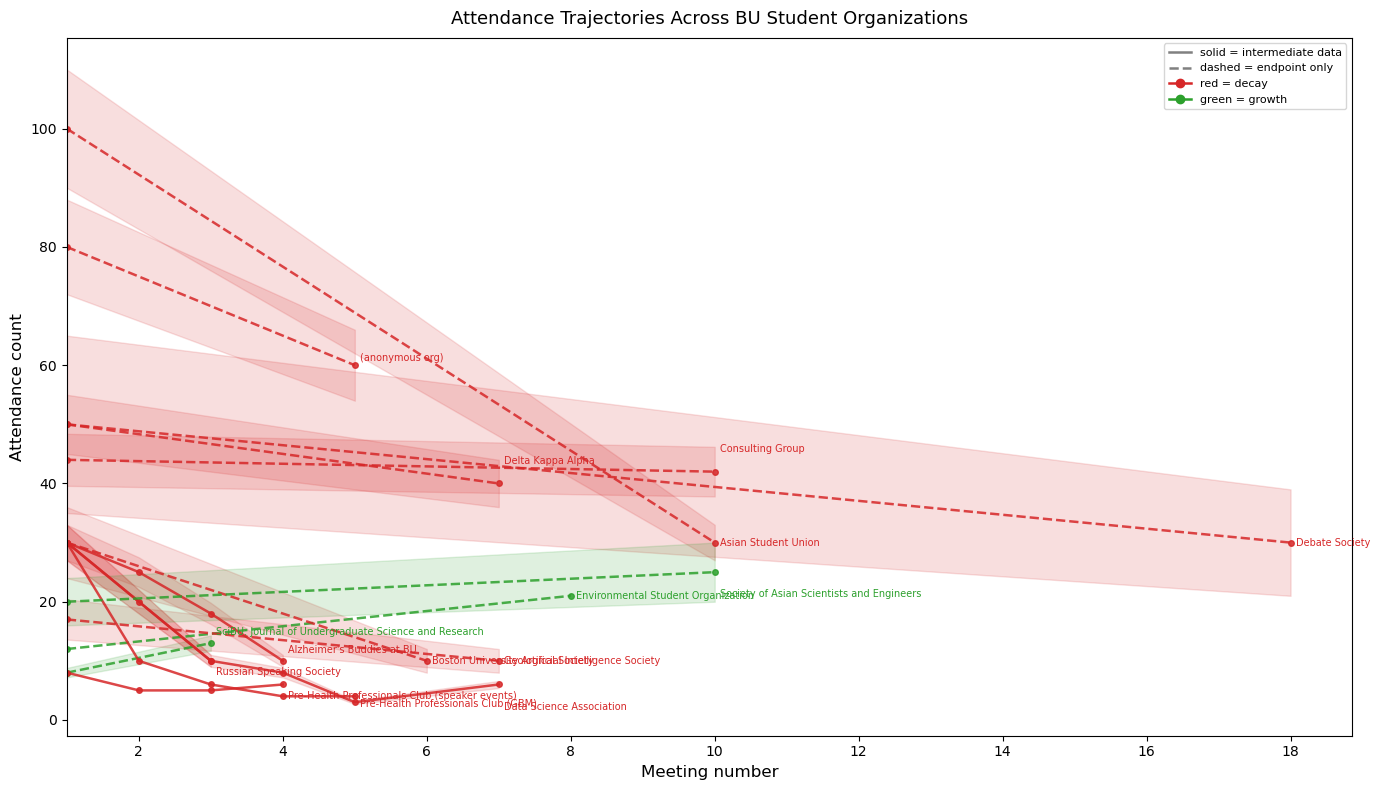

In [22]:
from matplotlib.lines import Line2D
from collections import defaultdict

CONFIDENCE_BAND = {
    "Exact counts from sign-in logs": 0.0,
    "Estimated but close": 0.10,
    "Rough estimate": 0.20,
    "Very rough estimate": 0.30,
}

# Precompute all trajectory data
trajectories = []
for _, row in df_rec.iterrows():
    name = row["Q1"]
    n_meetings = int(row["Q6"])
    first, recent = row["Q7"], row["Q8"]
    color = "#d62728" if recent < first else "#2ca02c"
    band_frac = CONFIDENCE_BAND.get(str(row["Q13"]).strip(), 0.10)

    if name in intermediate_sequences:
        seq = intermediate_sequences[name]
        xs = [i + 1 for i, v in enumerate(seq) if v is not None]
        ys = [v for v in seq if v is not None]
        linestyle = "-"
    else:
        xs = [1, n_meetings]
        ys = [first, recent]
        linestyle = "--"

    trajectories.append((name, xs, ys, color, linestyle, band_frac))

# Assign vertical annotation offsets (points) for orgs sharing the same final x.
# Use a larger step when adjacent final-y values are within 8 units (bottom cluster).
x_groups = defaultdict(list)
for name, xs, ys, *_ in trajectories:
    x_groups[xs[-1]].append((ys[-1], name))

annotation_offsets = {}
for fx, group in x_groups.items():
    group_sorted = sorted(group)
    n = len(group_sorted)
    if n > 1:
        min_adj_gap = min(b[0] - a[0] for a, b in zip(group_sorted, group_sorted[1:]))
        step = 16 if min_adj_gap < 8 else 10
    else:
        step = 10
    offsets = [(i - (n - 1) / 2) * step for i in range(n)]
    for (fy, name), offset in zip(group_sorted, offsets):
        annotation_offsets[name] = offset

# Plot
fig, ax = plt.subplots(figsize=(14, 8))

for name, xs, ys, color, linestyle, band_frac in trajectories:
    ys_arr = np.array(ys, dtype=float)
    if band_frac > 0:
        ax.fill_between(xs, ys_arr * (1 - band_frac), ys_arr * (1 + band_frac),
                        color=color, alpha=0.15)
    ax.plot(xs, ys, color=color, linestyle=linestyle, linewidth=1.8,
            marker="o", markersize=4, alpha=0.85)
    y_off = annotation_offsets.get(name, 0)
    ax.annotate(name, xy=(xs[-1], ys[-1]), xytext=(4, y_off),
                textcoords="offset points", fontsize=7,
                color=color, va="center", ha="left")

meta = [
    Line2D([0], [0], color="gray", linestyle="-", linewidth=1.8, label="solid = intermediate data"),
    Line2D([0], [0], color="gray", linestyle="--", linewidth=1.8, label="dashed = endpoint only"),
    Line2D([0], [0], color="#d62728", linewidth=1.8, marker="o", label="red = decay"),
    Line2D([0], [0], color="#2ca02c", linewidth=1.8, marker="o", label="green = growth"),
]
ax.legend(handles=meta, fontsize=8, loc="upper right", framealpha=0.8)

ax.set_xlim(left=1)
ax.set_xlabel("Meeting number", fontsize=12)
ax.set_ylabel("Attendance count", fontsize=12)
ax.set_title("Attendance Trajectories Across BU Student Organizations", fontsize=13, pad=10)
plt.tight_layout()
plt.show()

## Visualization 2: Attendance Slope by Organization

Each bar represents one organization's attendance slope — 
the average change in attendance per meeting across the semester.

A negative slope (red) means the org lost attendance on average 
each meeting. A positive slope (green) means it gained.

12 of 15 organizations show negative slopes. A sign test confirms 
this imbalance is statistically significant (p = 0.0176), suggesting 
attendance decay is not random variation but a systematic pattern.

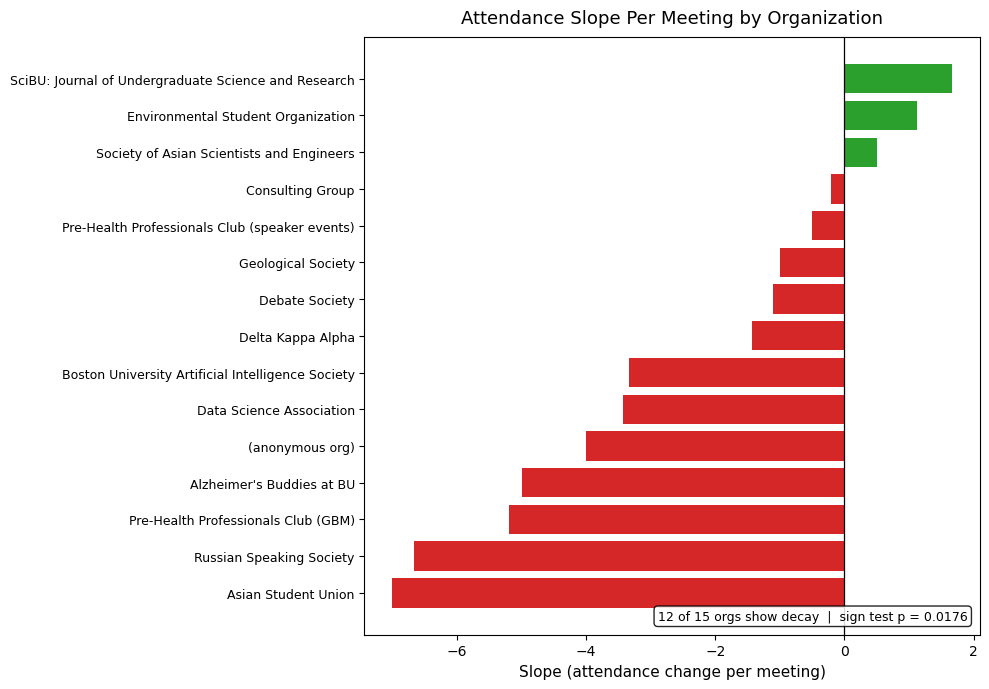

In [23]:
df_rec["slope"] = (df_rec["Q8"] - df_rec["Q7"]) / df_rec["Q6"]
ordered = df_rec.sort_values("slope").reset_index(drop=True)

colors = ["#d62728" if s < 0 else "#2ca02c" for s in ordered["slope"]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(ordered)), ordered["slope"], color=colors)
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels(ordered["Q1"], fontsize=9)
ax.axvline(0, color="black", linewidth=0.9)
ax.set_xlabel("Slope (attendance change per meeting)", fontsize=11)
ax.set_title("Attendance Slope Per Meeting by Organization", fontsize=13, pad=10)
ax.annotate(
    "12 of 15 orgs show decay  |  sign test p = 0.0176",
    xy=(0.98, 0.02), xycoords="axes fraction",
    fontsize=9, ha="right", va="bottom",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85),
)
plt.tight_layout()
plt.show()

## Statistical Test: Sign Test on Slopes

The primary statistical question is simple: are negative slopes 
more common than chance would predict?

Under the null hypothesis that ADC does not exist, we would expect 
roughly equal numbers of positive and negative slopes. We test this 
using a **binomial sign test** — a nonparametric test that asks only 
whether the direction of change is systematically negative, making 
no assumptions about the distribution of slopes.

- H₀: P(negative slope) = 0.5 (no systematic decay)
- H₁: P(negative slope) > 0.5 (systematic decay exists)

In [24]:
from scipy.stats import binomtest

# count negative slopes
n_negative = (df_rec['slope'] < 0).sum()
n_total = len(df_rec)
n_positive = n_total - n_negative

# one-sided binomial sign test
result = binomtest(int(n_negative), n_total, 0.5, alternative='greater')

print(f"Total orgs: {n_total}")
print(f"Negative slopes (decay): {n_negative}")
print(f"Positive slopes (growth): {n_positive}")
print(f"Proportion decaying: {n_negative/n_total:.1%}")
print(f"Sign test p-value: {result.pvalue:.4f}")

if result.pvalue < 0.05:
    print("→ Result is statistically significant at α = 0.05")
    print("→ Reject H₀: attendance decay is not random variation")
else:
    print("→ Result is not statistically significant at α = 0.05")

Total orgs: 15
Negative slopes (decay): 12
Positive slopes (growth): 3
Proportion decaying: 80.0%
Sign test p-value: 0.0176
→ Result is statistically significant at α = 0.05
→ Reject H₀: attendance decay is not random variation


The sign test is deliberately conservative. It counts only the 
direction of change, not its magnitude. This means our result 
likely underestimates the true effect size. Even this minimal 
test reaches significance.

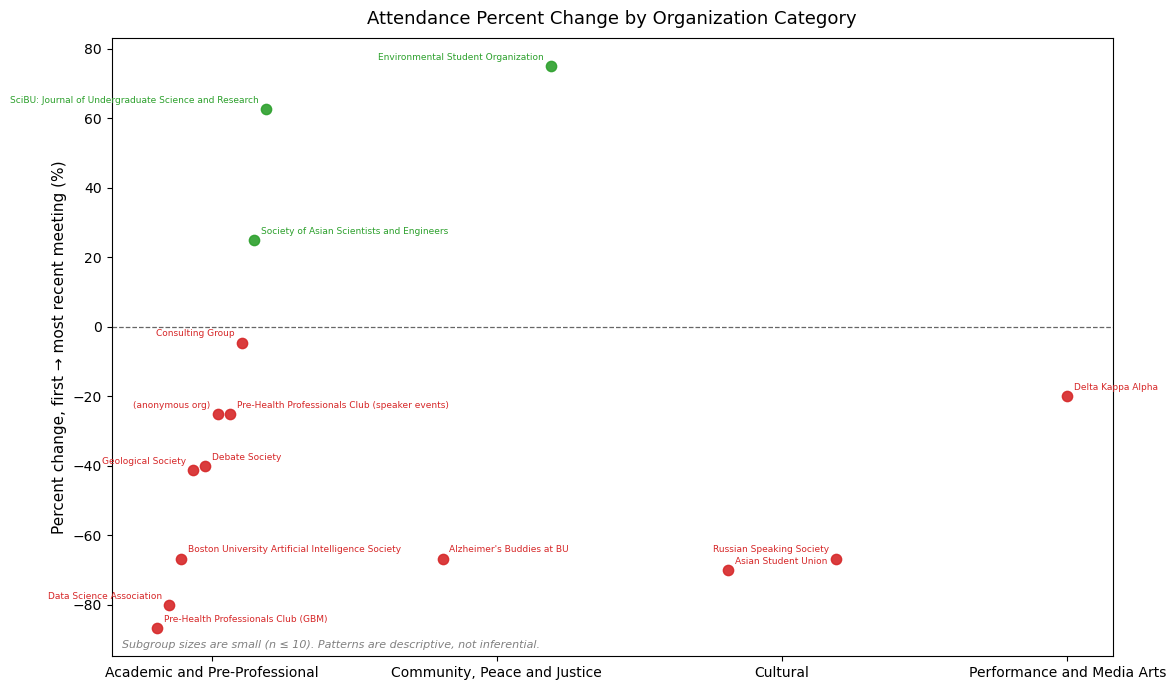

In [25]:
if "pct_change" not in df_rec.columns:
    df_rec["pct_change"] = (df_rec["Q8"] - df_rec["Q7"]) / df_rec["Q7"] * 100

categories = sorted(df_rec["Q2"].unique())
cat_to_x = {c: i for i, c in enumerate(categories)}
jitter_width = 0.38

# Spread dots within each category by pct_change rank to reduce overlap
jitter_positions = {}
for cat in categories:
    sub = df_rec[df_rec["Q2"] == cat].sort_values("pct_change")
    n = len(sub)
    for rank, idx in enumerate(sub.index):
        jitter = (rank / (n - 1) - 0.5) * jitter_width if n > 1 else 0
        jitter_positions[idx] = cat_to_x[cat] + jitter

fig, ax = plt.subplots(figsize=(12, 7))

for i, row in df_rec.iterrows():
    xpos = jitter_positions[i]
    pct = row["pct_change"]
    color = "#d62728" if pct < 0 else "#2ca02c"
    ax.scatter(xpos, pct, color=color, s=55, zorder=3, alpha=0.9)
    # Alternate label side by rank within category to reduce overlap
    sub = df_rec[df_rec["Q2"] == row["Q2"]].sort_values("pct_change")
    rank = list(sub.index).index(i)
    ha = "left" if rank % 2 == 0 else "right"
    xoff = 5 if ha == "left" else -5
    ax.annotate(row["Q1"], xy=(xpos, pct), xytext=(xoff, 3),
                textcoords="offset points", fontsize=6.5,
                color=color, va="bottom", ha=ha)

ax.axhline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.6)
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylabel("Percent change, first → most recent meeting (%)", fontsize=11)
ax.set_title("Attendance Percent Change by Organization Category", fontsize=13, pad=10)
ax.annotate(
    "Subgroup sizes are small (n ≤ 10). Patterns are descriptive, not inferential.",
    xy=(0.01, 0.01), xycoords="axes fraction",
    fontsize=8, ha="left", va="bottom", color="gray", style="italic",
)
plt.tight_layout()
plt.show()

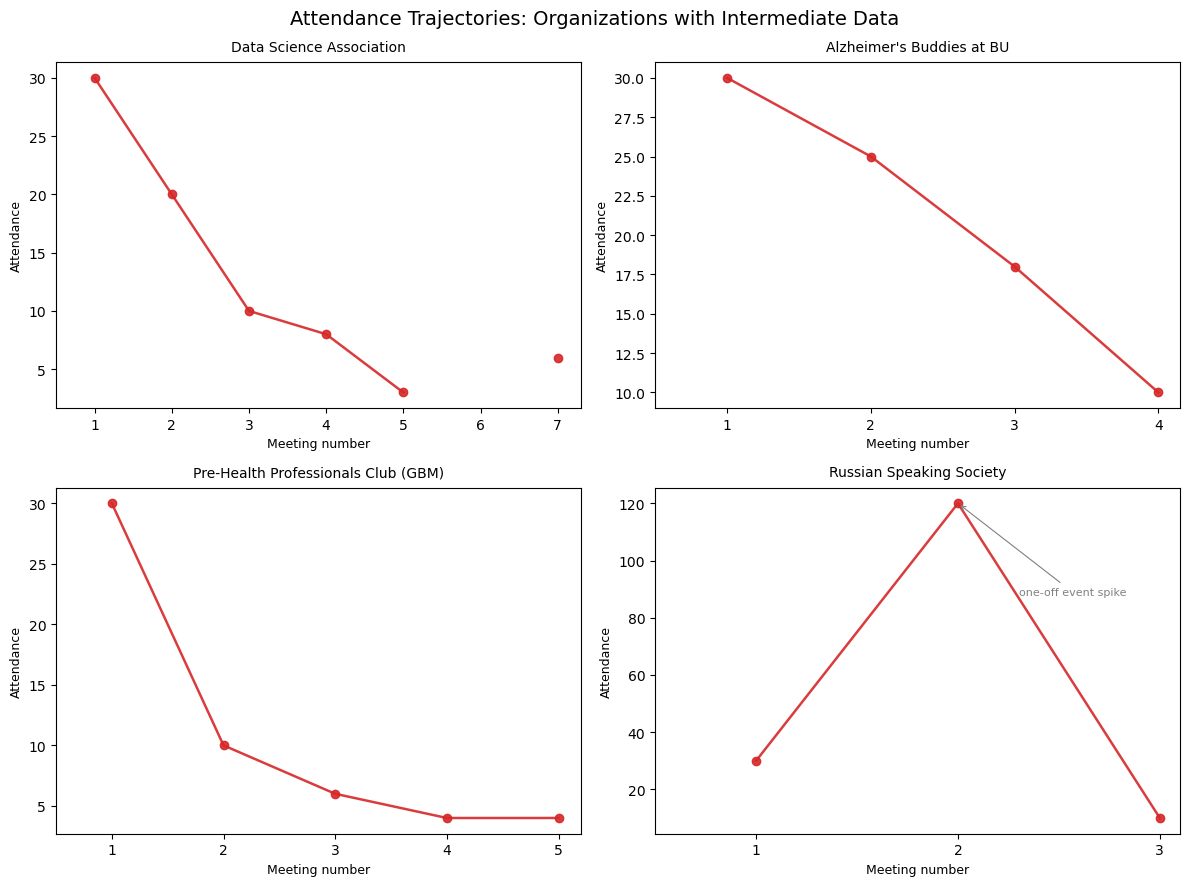

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Attendance Trajectories: Organizations with Intermediate Data", fontsize=14)

viz4_orgs = [
    ("Data Science Association",            [30, 20, 10, 8, 3, None, 6]),
    ("Alzheimer's Buddies at BU",           [30, 25, 18, 10]),
    ("Pre-Health Professionals Club (GBM)", [30, 10, 6, 4, 4]),
    ("Russian Speaking Society",            [30, 120, 10]),
]

for ax, (name, seq) in zip(axes.flat, viz4_orgs):
    row = df_rec[df_rec["Q1"] == name].iloc[0]
    color = "#d62728" if row["Q8"] < row["Q7"] else "#2ca02c"
    xs = list(range(1, len(seq) + 1))
    ys = [float(v) if v is not None else np.nan for v in seq]
    ax.plot(xs, ys, color=color, linewidth=1.8, marker="o", markersize=6, alpha=0.9)
    if name == "Russian Speaking Society":
        ax.annotate(
            "one-off event spike",
            xy=(2, 120), xytext=(2.3, 88),
            fontsize=8, color="gray",
            arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
        )
    ax.set_title(name, fontsize=10, pad=8)
    ax.set_xlabel("Meeting number", fontsize=9)
    ax.set_ylabel("Attendance", fontsize=9)
    ax.set_xlim(left=0.5)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()